In [ ]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


In [ ]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


In [ ]:

BASE_PATHHASIL = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv1/norm/dwt/"

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


def build_cnn_tow_ids(input_shape=(64, 64, 3)):

    inputs = layers.Input(shape=input_shape)

    # =========================================================
    # Block A
    # SeparableConv + ReLU
    # SeparableConv + ReLU
    # BatchNorm
    # MaxPooling
    # =========================================================

    x = layers.SeparableConv2D(
        32, (3,3),
        padding="same",
        use_bias=False
    )(inputs)
    x = layers.ReLU()(x)

    x = layers.SeparableConv2D(
        32, (3,3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.ReLU()(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2,2))(x)

    # =========================================================
    # Block B (Residual Block)
    #
    # shortcut:
    # Conv1x1 + BN
    #
    # main:
    # SepConv + ReLU
    # SepConv + ReLU
    # BN
    #
    # output:
    # Add + ReLU
    # =========================================================

    shortcut = layers.Conv2D(
        64,
        (1,1),
        padding="same",
        use_bias=False
    )(x)

    shortcut = layers.BatchNormalization()(shortcut)

    y = layers.SeparableConv2D(
        64,
        (3,3),
        padding="same",
        use_bias=False
    )(x)
    y = layers.ReLU()(y)

    y = layers.SeparableConv2D(
        64,
        (3,3),
        padding="same",
        use_bias=False
    )(y)
    y = layers.ReLU()(y)

    y = layers.BatchNormalization()(y)

    x = layers.Add()([y, shortcut])
    x = layers.ReLU()(x)

    # =========================================================
    # Block C
    #
    # SepConv + ReLU
    # GlobalAveragePooling
    # Dense + ReLU
    # Dense + ReLU
    # Dropout
    # Dense + Sigmoid
    # =========================================================

    x = layers.SeparableConv2D(
        128,
        (3,3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation="relu")(x)

    x = layers.Dense(256, activation="relu")(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

In [ ]:

train_data = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_test_dwt.npz"))
val_data   = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_eval_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

X_val   = val_data["X"]
y_val   = val_data["y"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_val.shape, y_val.shape)

In [ ]:
tf.keras.backend.clear_session()

model = build_cnn_tow_ids()
model.summary()


In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    
)


2026-05-22 22:27:54.679233: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1485_0', 44 bytes spill stores, 44 bytes spill loads

2026-05-22 22:27:54.902925: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1485', 484 bytes spill stores, 484 bytes spill loads

2026-05-22 22:27:55.585240: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2261', 36 bytes spill stores, 44 bytes spill loads

2026-05-22 22:27:55.829367: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2263', 32 bytes spill stores, 32 bytes spill loads

2026-05-22 22:27:55.964567: I extern

205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7396 - loss: 0.5020 - precision: 0.7387 - recall: 0.8293

2026-05-22 22:28:06.369026: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1485_0', 36 bytes spill stores, 36 bytes spill loads

2026-05-22 22:28:06.940854: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1485', 488 bytes spill stores, 488 bytes spill loads

2026-05-22 22:28:07.056110: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2261', 28 bytes spill stores, 32 bytes spill loads

2026-05-22 22:28:08.042346: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2263', 28 bytes spill stores, 32 bytes spill loads

2026-05-22 22:28:08.287814: I extern

206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7400 - loss: 0.5014 - precision: 0.7392 - recall: 0.8292

2026-05-22 22:28:17.872184: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 64 bytes spill stores, 64 bytes spill loads



206/206 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.8204 - loss: 0.3857 - precision: 0.8417 - recall: 0.8090 - val_accuracy: 0.6856 - val_loss: 0.7310 - val_precision: 0.6856 - val_recall: 1.0000
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9047 - loss: 0.2481 - precision: 0.9370 - recall: 0.8769 - val_accuracy: 0.6856 - val_loss: 0.6664 - val_precision: 0.6856 - val_recall: 1.0000
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9183 - loss: 0.2166 - precision: 0.9468 - recall: 0.8940 - val_accuracy: 0.6863 - val_loss: 0.9177 - val_precision: 0.6862 - val_recall: 0.9995
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9493 - loss: 0.1466 - precision: 0.9704 - recall: 0.9315 - val_accuracy: 0.9422 - val_loss: 0.1619 - val_precision: 0.9873 - val_recall: 0.9276
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9654 - loss: 0.1056 - precision: 0.9814 - recall: 0.9518 - val_accuracy: 0.9415 - val_loss: 0.1658 

In [8]:
# =========================
# CELL 1
# =========================

import numpy as np
from sklearn.metrics import roc_curve

# prediksi probabilitas
y_prob = model.predict(X_test).ravel()

# label asli
y_true = y_test

# =========================
# EVALUASI DEFAULT THRESHOLD 0.5
# =========================

default_threshold = 0.5
y_pred_default = (y_prob >= default_threshold).astype(int)

# =========================
# CARI THRESHOLD TERBAIK
# =========================
# strategi:
# cari threshold dengan F1 tertinggi

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0

for th in thresholds:

    y_pred_temp = (y_prob >= th).astype(int)

    TP = np.sum((y_true == 1) & (y_pred_temp == 1))
    TN = np.sum((y_true == 0) & (y_pred_temp == 0))
    FP = np.sum((y_true == 0) & (y_pred_temp == 1))
    FN = np.sum((y_true == 1) & (y_pred_temp == 0))

    precision = TP / (TP + FP + 1e-12)
    recall = TP / (TP + FN + 1e-12)

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("Best Threshold:", best_threshold)
print("Best F1 Score :", best_f1)

# prediksi final threshold terbaik
y_pred_best = (y_prob >= best_threshold).astype(int)

186/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2026-05-22 22:30:24.711541: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_138', 64 bytes spill stores, 64 bytes spill loads



194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step
Best Threshold: 0.13
Best F1 Score : 0.9276954054543795


In [9]:
# =========================
# CELL 2
# =========================

from sklearn.metrics import confusion_matrix

# ===== DEFAULT 0.5 =====
cm_default = confusion_matrix(y_true, y_pred_default)

TN_d, FP_d, FN_d, TP_d = cm_default.ravel()

print("=== Confusion Matrix (Threshold = 0.5) ===")
print(cm_default)

# ===== BEST THRESHOLD =====
cm_best = confusion_matrix(y_true, y_pred_best)

TN_b, FP_b, FN_b, TP_b = cm_best.ravel()

print("\n=== Confusion Matrix (Best Threshold) ===")
print(cm_best)

=== Confusion Matrix (Threshold = 0.5) ===
[[3271   25]
 [ 386 2502]]

=== Confusion Matrix (Best Threshold) ===
[[3255   41]
 [ 354 2534]]


In [10]:
# =========================
# CELL 3
# =========================

def calculate_metrics(TN, FP, FN, TP):

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP + 1e-12)

    recall = TP / (TP + FN + 1e-12)

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    FPR = FP / (FP + TN + 1e-12)

    FNR = FN / (FN + TP + 1e-12)

    return accuracy, precision, recall, f1, FPR, FNR


# ===== DEFAULT =====
metrics_default = calculate_metrics(TN_d, FP_d, FN_d, TP_d)

# ===== BEST =====
metrics_best = calculate_metrics(TN_b, FP_b, FN_b, TP_b)

In [11]:
# =========================
# CELL 4
# =========================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FNR"
]

print("========================================")
print("THRESHOLD = 0.5")
print("========================================")

for name, value in zip(metric_names, metrics_default):
    print(f"{name:10}: {value:.6f}")

print("\n")

print("========================================")
print(f"BEST THRESHOLD = {best_threshold:.2f}")
print("========================================")

for name, value in zip(metric_names, metrics_best):
    print(f"{name:10}: {value:.6f}")

THRESHOLD = 0.5
Accuracy  : 0.933538
Precision : 0.990107
Recall    : 0.866343
F1-score  : 0.924100
FPR       : 0.007585
FNR       : 0.133657


BEST THRESHOLD = 0.13
Accuracy  : 0.936125
Precision : 0.984078
Recall    : 0.877424
F1-score  : 0.927695
FPR       : 0.012439
FNR       : 0.122576


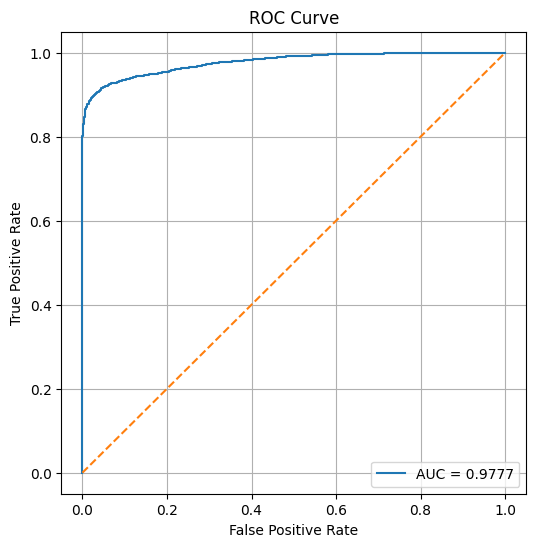

In [12]:
# =========================
# CELL 5
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()